In [1]:
import re
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm
from clearml import Task, Logger


In [20]:
# Конфигурация
config = {
    "project_name": "WikiText_Global_Search",
    "rnn_type": "LSTM",
    "n_epochs": 15,
    "weight_decay": 1e-5,
    "hidden_dim": 252,
    "embedding_dim": 126,
    "batch_size": 64,
    "seq_len": 32,
    "num_layers": 2,
    "lr": 0.001,
    "dropout": 0.5,
    "min_word_freq": 2,
    "max_norm": 1,
    "max_texts_count": 1000 # this params exists for local testing

}

In [4]:
# Этап 0. Подготовка - done
# Есть ячейка с импортами и фиксированным seed = 42. - done
# Датасет WikiText-2 загружен. - done

np.random.seed(42)
torch.manual_seed(42)
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

Train size: 36718
Validation size: 3760
Test size: 4358

Статистика по количеству слов в тексте:
Среднее: 55.88
Медиана: 8.00
5-й перцентиль: 0.00
95-й перцентиль: 213.15


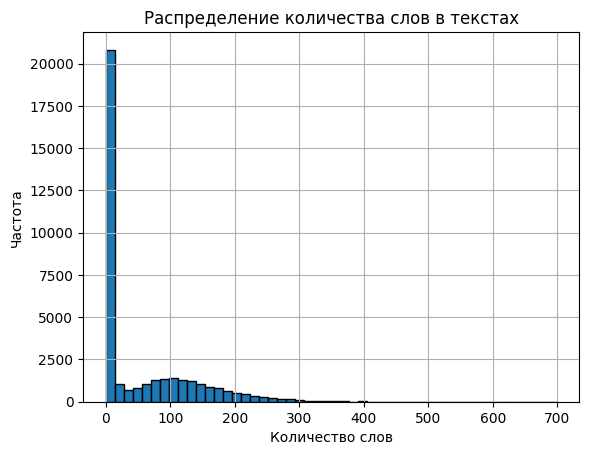


Статистика по количеству слов в тексте:
Среднее: 118.69
Медиана: 108.00
5-й перцентиль: 44.00
95-й перцентиль: 229.00


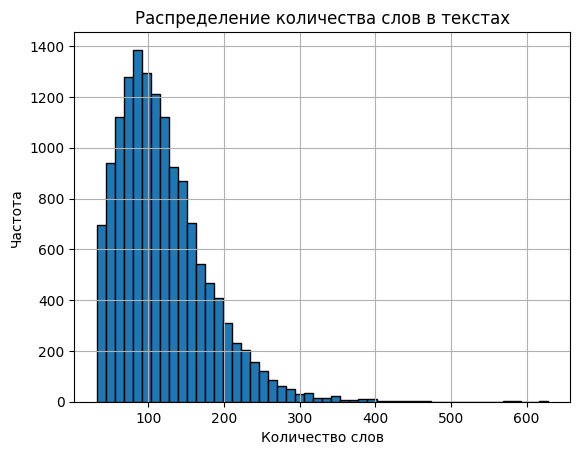

Количество слов в словаре:  38087
Исходный текст:  senj no valkyria 3 unrecorded ch
Токенизированный:  [1, 2, 3, 4, 5, 9297]
Декодированный обратно в слова: ['senj', 'no', 'valkyria', '3', 'unrecorded', 'ch']
['senj', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '3', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', 'is', 'a', 'tactical', 'role', 'playing', 'video', 'game', 'developed']
['no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '3', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', 'is', 'a', 'tactical', 'role', 'playing', 'video', 'game', 'developed', 'by']
Этап 1 - done


In [21]:
# Этап 1. Данные - done
# Проведён разведочный анализ (примеры текстов, статистики, визуализации). - done
# Реализована пословная токенизация с построением словаря. - done
# Сформированы последовательности для обучения (вход сдвинут на 1 токен относительно таргета). - done
# Созданы torch.Dataset и DataLoader для train/val/test. - done
# Код этапа рабочий, ошибок не вызывает. - done


# Проведён разведочный анализ (примеры текстов, статистики, визуализации).
train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

texts = train_data["text"]
word_counts = [len(text.split()) for text in texts]

# Добавим две функции: чистку текста и построение графиков статистики
def clean_text(texts, min_seq_len):
    res = []
    for text in texts:
        text = text.lower()  # к нижнему регистру
        text = re.sub(r"[^a-z0-9 ]+", " ", text)  # оставить только буквы и цифры
        text = re.sub(r"\s+", " ", text).strip()  # убрать дублирующиеся пробелы
        if len(text.split()) >= min_seq_len:
            res.append(text)
    return res

def show_stat(texts):
    word_counts = [len(text.split()) for text in texts]
    print("\nСтатистика по количеству слов в тексте:")
    print(f"Среднее: {np.mean(word_counts):.2f}")
    print(f"Медиана: {np.median(word_counts):.2f}")
    print(f"5-й перцентиль: {np.percentile(word_counts, 5):.2f}")
    print(f"95-й перцентиль: {np.percentile(word_counts, 95):.2f}")


    # Гистограмма распределения длины
    plt.hist(word_counts, bins=50, edgecolor='black')
    plt.title("Распределение количества слов в текстах")
    plt.xlabel("Количество слов")
    plt.ylabel("Частота")
    plt.grid(True)
    plt.show() 


show_stat(texts)

# Вывод: очень много пустых текстов, нужна очистка и затем повторный анализ.
cleaned_texts = clean_text(texts, config["seq_len"])
show_stat(cleaned_texts)


# Реализована пословная токенизация с построением словаря.
class WikiTokenizer:
    def __init__(self, min_freq=5):
        self.itos = {0: "<unk>"}
        self.stoi = {"<unk>": 0}
        self.min_freq = min_freq

    def build_vocabulary(self, texts):
        freqs = Counter()
        for t in texts: 
            freqs.update(re.findall(r"[\w']+", t.lower()))
        idx = 1
        for word, freq in freqs.items():
            if freq >= self.min_freq:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1
    
    def encode(self, text):
        return [self.stoi.get(w, 0) for w in re.findall(r"[\w']+", text.lower())]
    
    def decode(self, tokens):
        return [self.itos.get(int(t), "<unk>") for t in tokens]

    def __len__(self):
        return len(self.itos)

# Сформированы последовательности для обучения (вход сдвинут на 1 токен относительно таргета).
class WikiDataset(Dataset):
    def __init__(self, texts, tokenizer, seq_len):
        self.samples = []
        for t in texts:
            tokens = tokenizer.encode(t)
            for i in range(0, len(tokens) - seq_len, seq_len):
                chunk = torch.tensor(tokens[i:i+seq_len], dtype=torch.long)
                if len(chunk) == seq_len:
                    self.samples.append(chunk)

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, i): 
        return self.samples[i][:-1], self.samples[i][1:]

tokenizer = WikiTokenizer(min_freq=config["min_word_freq"])
tokenizer.build_vocabulary(cleaned_texts)
print("Количество слов в словаре: ", len(tokenizer))

# Проверим, что токенайзер работает корректно
sample = cleaned_texts[0][:config["seq_len"]]
encoded_sample = tokenizer.encode(sample)
decoded_sample = tokenizer.decode(encoded_sample)

print("Исходный текст: ", sample)
print("Токенизированный: ", encoded_sample)
print("Декодированный обратно в слова:", decoded_sample)

# Созданы torch.Dataset и DataLoader для train/val/test.
if config["max_texts_count"] > 0:
    cleaned_texts = cleaned_texts[:config["max_texts_count"]]
    val_data = val_data.select(range(int(config["max_texts_count"]*0.05)))

train_dataset = WikiDataset(cleaned_texts, tokenizer, seq_len=config["seq_len"])
val_dataset = WikiDataset(val_data["text"], tokenizer, seq_len=config["seq_len"])

train_dataloader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=config["batch_size"])


# Проверяем, что __getitem__ возвращает корректные данные
x, y = train_dataset.__getitem__(0)
print(tokenizer.decode(x))
print(tokenizer.decode(y))

# Код этапа рабочий, ошибок не вызывает. - Done.
print("Этап 1 - done")



Epoch 0:   0%|          | 0/54 [00:00<?, ?it/s]

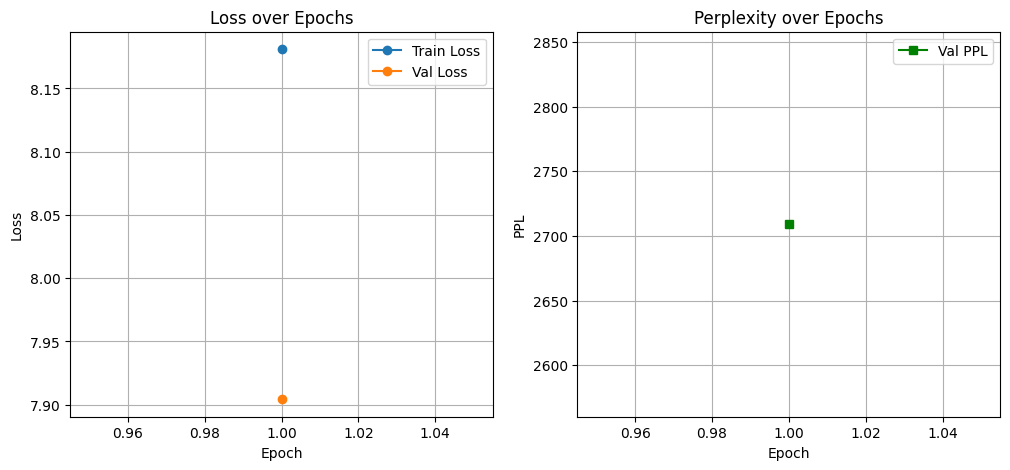

Epoch 1: Train Loss: 8.1810 | Val PPL: 2709.07


Epoch 1:   0%|          | 0/54 [00:00<?, ?it/s]

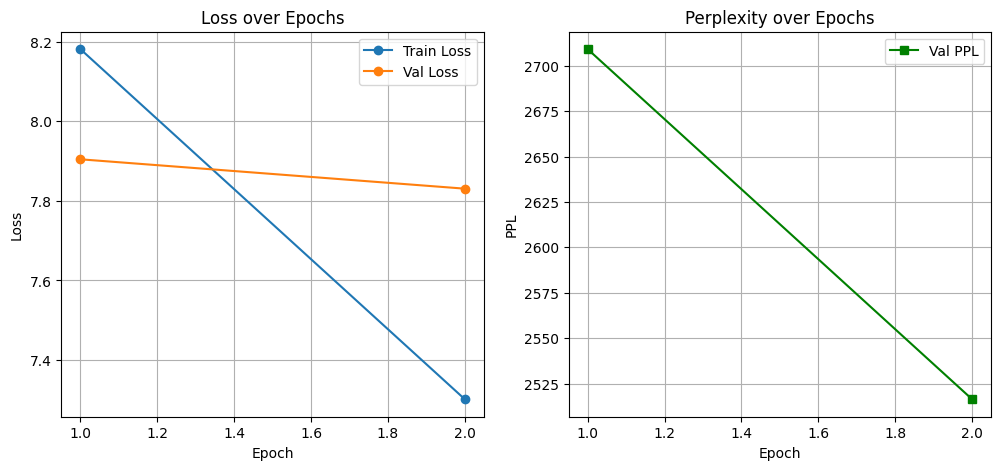

Epoch 2: Train Loss: 7.3015 | Val PPL: 2516.39


Epoch 2:   0%|          | 0/54 [00:00<?, ?it/s]

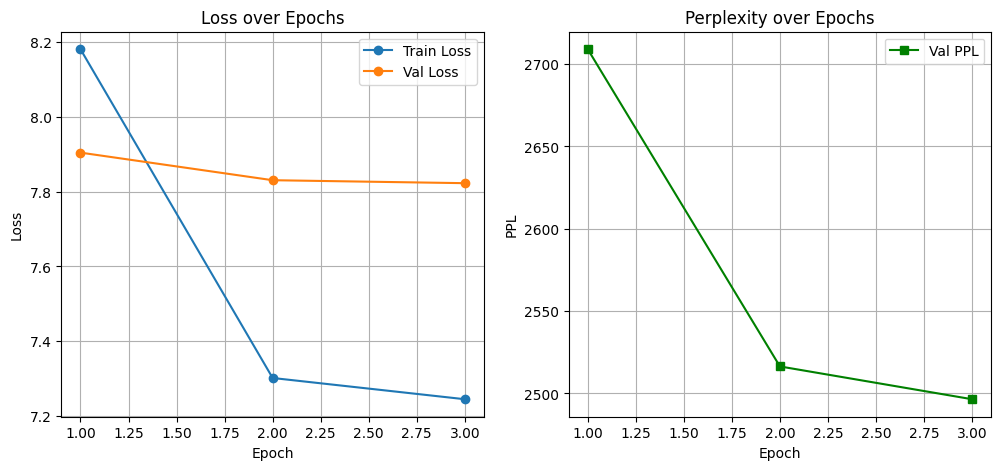

Epoch 3: Train Loss: 7.2447 | Val PPL: 2496.48


Epoch 3:   0%|          | 0/54 [00:00<?, ?it/s]

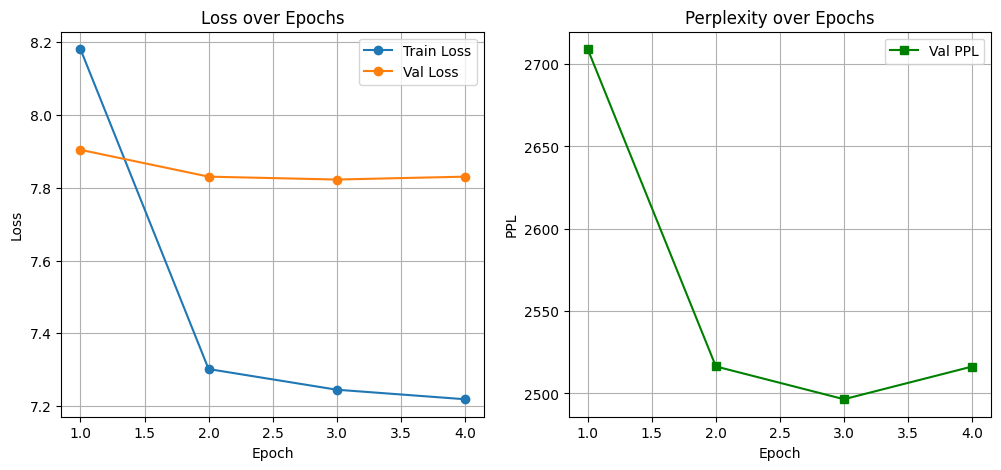

Epoch 4: Train Loss: 7.2185 | Val PPL: 2516.32


Epoch 4:   0%|          | 0/54 [00:00<?, ?it/s]

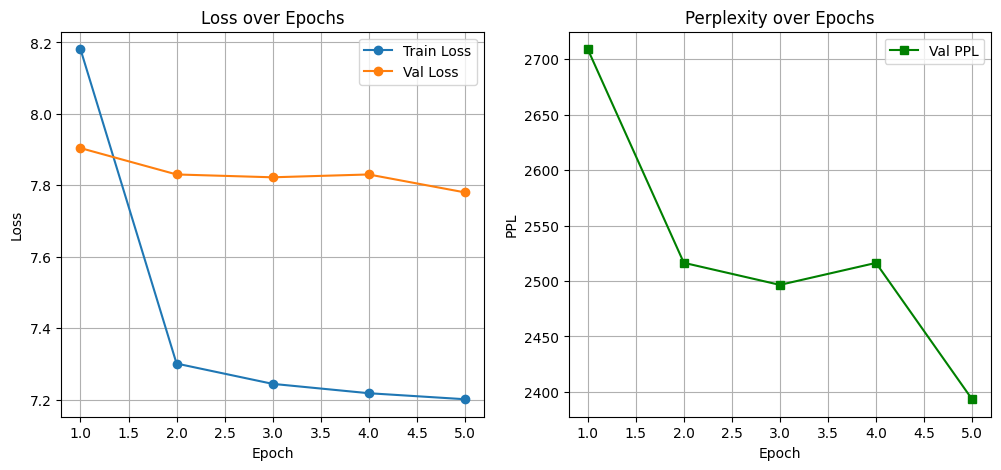

Epoch 5: Train Loss: 7.2017 | Val PPL: 2393.34


Epoch 5:   0%|          | 0/54 [00:00<?, ?it/s]

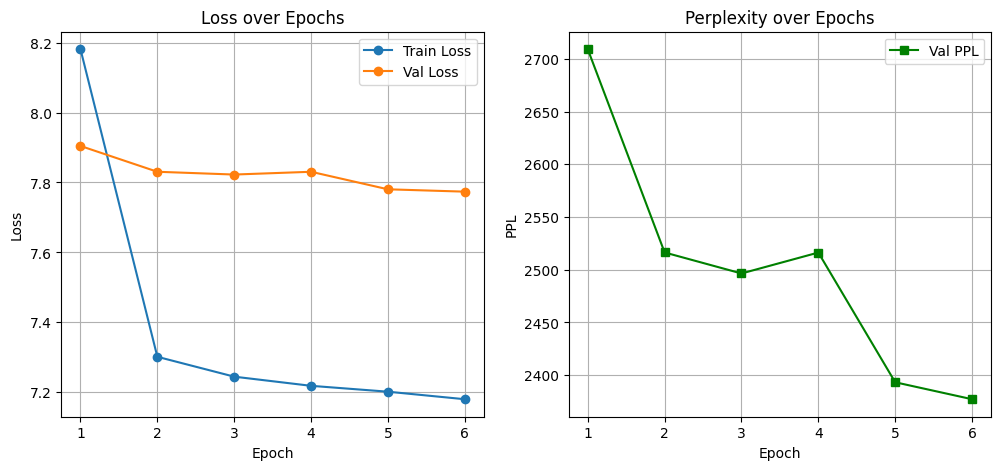

Epoch 6: Train Loss: 7.1802 | Val PPL: 2377.27


Epoch 6:   0%|          | 0/54 [00:00<?, ?it/s]

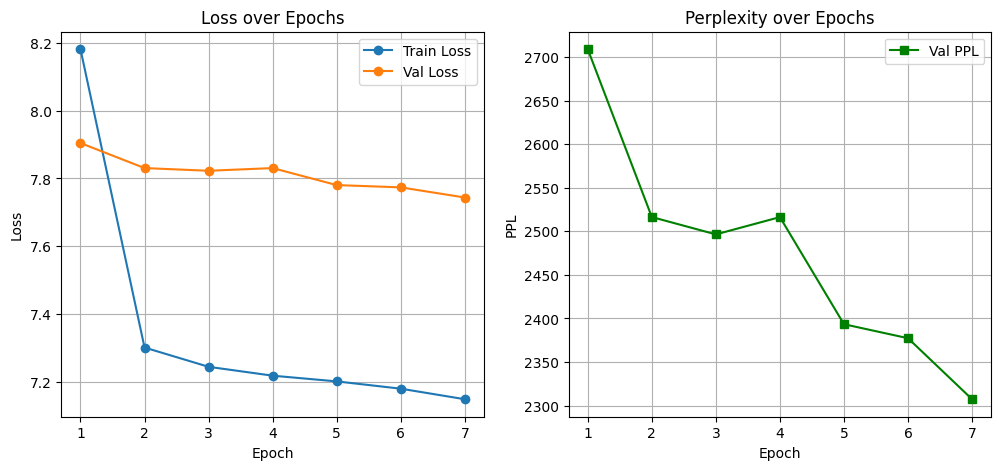

Epoch 7: Train Loss: 7.1491 | Val PPL: 2307.23


Epoch 7:   0%|          | 0/54 [00:00<?, ?it/s]

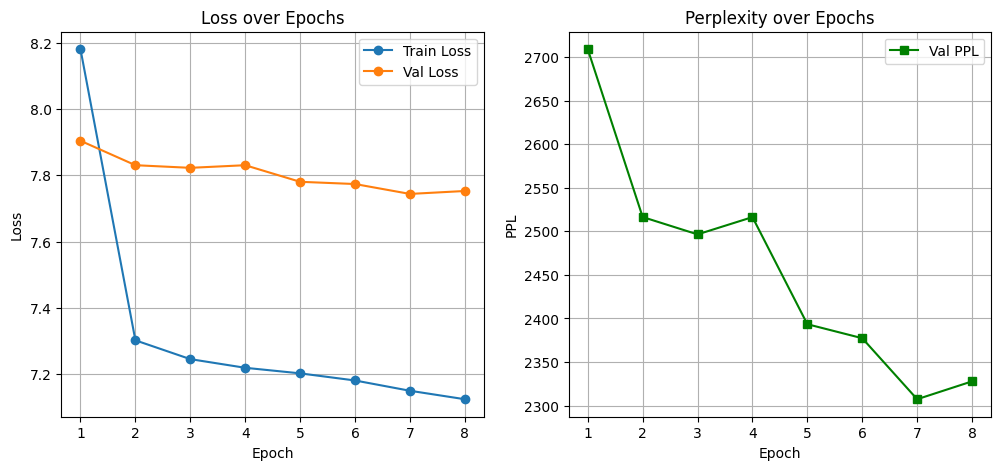

Epoch 8: Train Loss: 7.1236 | Val PPL: 2327.74


Epoch 8:   0%|          | 0/54 [00:00<?, ?it/s]

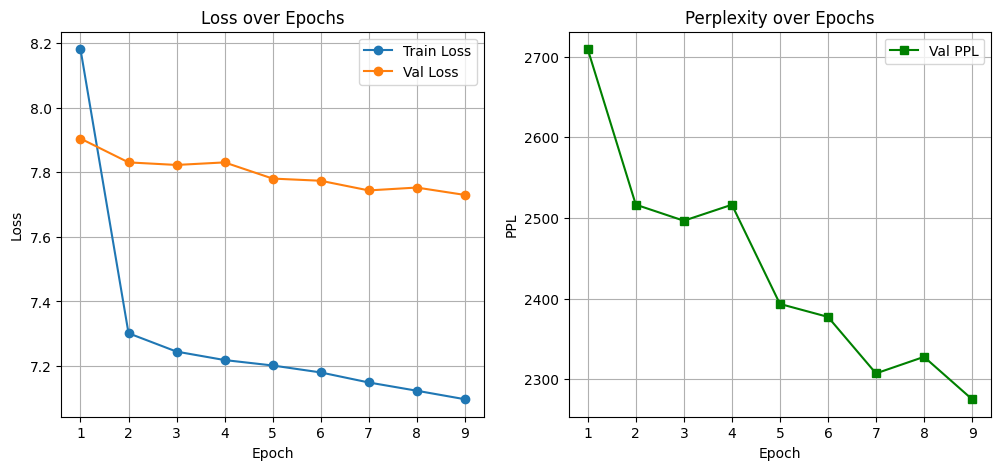

Epoch 9: Train Loss: 7.0973 | Val PPL: 2275.23


Epoch 9:   0%|          | 0/54 [00:00<?, ?it/s]

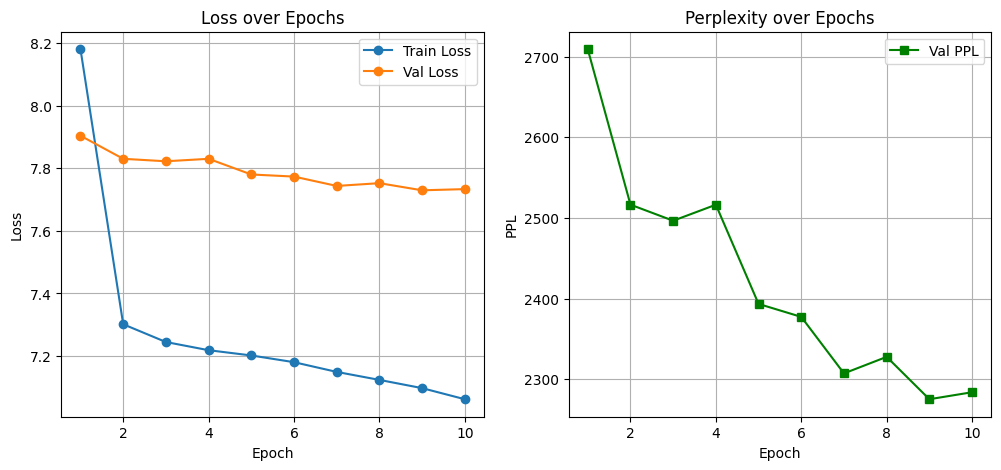

Epoch 10: Train Loss: 7.0618 | Val PPL: 2283.89


Epoch 10:   0%|          | 0/54 [00:00<?, ?it/s]

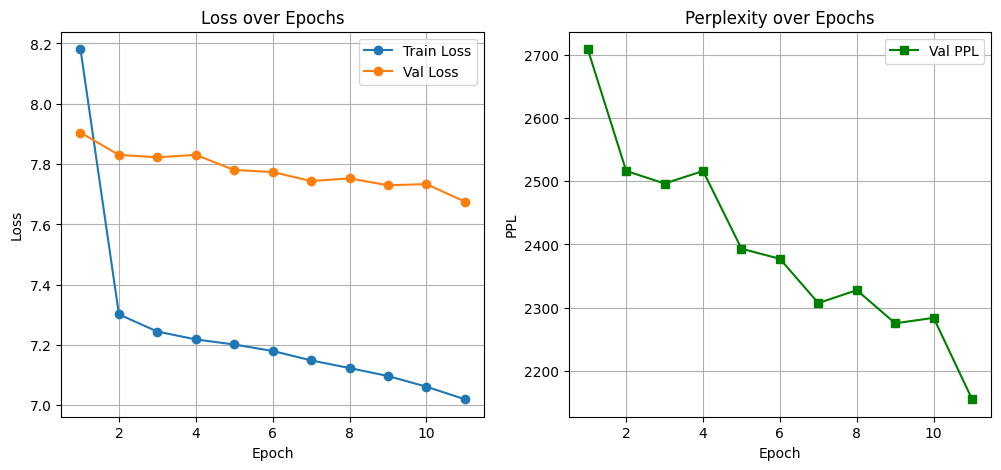

Epoch 11: Train Loss: 7.0202 | Val PPL: 2155.07


Epoch 11:   0%|          | 0/54 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [23]:
# Этап 2. LSTM-модель
# Реализован класс модели (Embedding + LSTM + Linear). - done
# Написан цикл обучения с выводом loss и perplexity. - done
# Применён gradient clipping. - done
# Модель обучена, val perplexity снижается.
# Построены графики обучения.
# Код этапа рабочий, ошибок не вызывает.


# Реализован класс модели (Embedding + LSTM + Linear).
class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, rnn_type='LSTM', n_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        else:
            raise Exception("Unknown rnn_type")
        self.fc = nn.Linear(hid_dim, vocab_size)
    
    def forward(self, x):
        out, _ = self.rnn(self.embedding(x))
        return self.fc(out)


class RNNTrainer:
    def __init__(self, tokenizer, train_loader, val_loader, config, task=None):
        self.tokenizer = tokenizer
        self.vocab_size = len(tokenizer)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = RNNModel(
            self.vocab_size, config["embedding_dim"], config["hidden_dim"],
            config["rnn_type"], config["num_layers"], config["dropout"]
        ).to(self.device)
        self.model.to(self.device)
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
        self.criterion = nn.CrossEntropyLoss()
        if task:
            self.task = task
            self.logger = Logger.current_logger()

        # Хранилище метрик
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_ppl': []
        }

    # Написан цикл обучения с выводом loss и perplexity.
    def train(self):
        best_loss = float('inf')
        patience_counter = 0

        for epoch in range(self.config["n_epochs"]):
            self.model.train()
            total_loss = 0
            for x, y in tqdm(self.train_loader, desc=f"Epoch {epoch}"):
                x, y = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(x)
                loss = self.criterion(logits.view(-1, self.vocab_size), y.view(-1))
                loss.backward()
                # Применён gradient clipping.
                nn.utils.clip_grad_norm_(self.model.parameters(), self.config["max_norm"])
                self.optimizer.step()
                total_loss += loss.item()
            avg_train_loss = total_loss / len(self.train_loader)
            # Валидация
            avg_val_loss, val_ppl = self.evaluate()
            
            # Сохранение истории
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            self.history['val_ppl'].append(val_ppl)
            
            # Визуализация
            self.plot_history()
            print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val PPL: {val_ppl:.2f}")

            # Early Stopping
            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= 2:
                    print("Early Stopping triggered!")
                    break
        
        if self.task:
            self.task.close()

    def evaluate(self):
        self.model.eval()
        v_loss = 0
        with torch.no_grad():
            for x, y in self.val_loader:
                x, y = x.to(self.device), y.to(self.device)
                out = self.model(x)
                v_loss += self.criterion(out.view(-1, self.vocab_size), y.view(-1)).item()
        avg_loss = v_loss / len(self.val_loader)
        return avg_loss, np.exp(avg_loss) 
    
    def check_predictions(self, num_examples=2):
        self.model.eval()
        with torch.no_grad():
            x, y = next(iter(self.val_loader))
            outputs = self.model.forward(x)
            predictions = outputs.argmax(dim=-1)
            
            print("\n" + "-"*30 + " СРЕЗ ПРЕДСКАЗАНИЙ " + "-"*30)
            for i in range(num_examples):
                print(f"\n[Пример {i+1}]")
                print(f"Контекст (X):  {self.tokenizer.decode(x[i])}")
                print(f"Ожидалось (Y): {self.tokenizer.decode(y[i])}")
                print(f"Модель выдала: {self.tokenizer.decode(predictions[i])}")

    def plot_history(self):
        epochs = range(1, len(self.history['train_loss']) + 1)
        
        plt.figure(figsize=(12, 5))
        
        # График Loss
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history['train_loss'], label='Train Loss', marker='o')
        plt.plot(epochs, self.history['val_loss'], label='Val Loss', marker='o')
        plt.title('Loss over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # График Perplexity
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history['val_ppl'], label='Val PPL', color='green', marker='s')
        plt.title('Perplexity over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('PPL')
        plt.legend()
        plt.grid(True)
        plt.show()


trainer = RNNTrainer(tokenizer, train_dataloader, val_dataloader, config)
trainer.train()


